# Мультиагентный пайплайн подготовки коммерческого предложения

Мультиагентная система на базе **LangGraph** и **Yandex AI Studio**, которая по запросу менеджера автоматически готовит коммерческое предложение: исследует клиента, подбирает сервисы из корпоративной базы знаний, уточняет требования и собирает финальный документ.

**Агенты:**
1. **RAG-агент** — по Vector Store с документацией Yandex AI Studio подбирает сервисы и оценивает стоимость
2. **Агент уточнения требований** — задаёт вопросы, формирует ТЗ
3. **Orchestration-агент** — объединяет все данные и генерирует готовое коммерческое предложение

# 1. Архитектура решения

```
┌─────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│                     Запрос менеджера                                                                    │
│  «Подготовь КП для компании X на внедрение AI-чатбота на основе инструментов Yandex AI Studio»          │
└──────────────────────────┬──────────────────────────────────────────────────────────────────────────────┘
                           │
                           ▼
┌──────────────────────────────────────────────────────────────┐
│               Orchestration-агент (LangGraph)                │
│                                                              │
│  ┌──────────────┐  ┌───────────────────────┐                 │
│  │  RAG-агент   │  │  Агент уточнения      │                 │
│  │              │  │  требований           │                 │
│  │ Vector Store │  │ Диалог с менеджером   │                 │
│  │ + file_search│  │ + формирование ТЗ     │                 │
│  └──────┬───────┘  └───────────┬───────────┘                 │
│         │                      │                             │
│         ▼                      ▼                             │
│  ┌─────────────────────────────────────────────────────┐     │
│  │              Сборка коммерческого предложения       │     │
│  │  • Описание решения    • Ценностное предложение     │     │
│  │  • Архитектура         • Расчёт стоимости           │     │
│  └─────────────────────────────────────────────────────┘     │
└──────────────────────────────────────────────────────────────┘
```

## Технологический стек

| Компонент | Технология |
|-----------|-----------|
| LLM | Yandex AI Studio (OpenAI-совместимый API) |
| RAG | Vector Store + file_search (нативный Yandex AI Studio) |
| Оркестрация | LangGraph (StateGraph) |
| Парсинг документации | curl_cffi (обход SmartCaptcha) + BeautifulSoup |


## Необходимые права

### Роли сервисного аккаунта (IAM)

| Компонент | Назначение | Роль |
|-----------|-----------|------|
| **AI agent** | Вызов агента, Tool Calling, Vector Store, file_search | `ai.assistants.editor` |
| **YandexGPT / DeepSeek** | Генерация текста (Responses API) | `ai.languageModels.user` |

## Описание ролей и их области действия:
- `ai.assistants.editor` — *Область действия: каталог и вложенные ресурсы.* Полный доступ к **AI-агентам Yandex AI Studio**: создание, настройка и использование агентов, работа с **Vector Store** и **file_search**.

- `ai.languageModels.user` — *Область действия: каталог и вложенные ресурсы.* Минимальная роль для работы с моделями генерации текста (YandexGPT, DeepSeek). Позволяет отправлять запросы к моделям.

### Области действия (scopes) API-ключа

| Scope | Назначение |
|-------|-----------|
| `yc.ai.foundationModels.execute` | Responses API, Tool Calling, Code Interpreter |
| `yc.ai.languageModels.execute` | Вызовы LLM |

**Сервисный аккаунт** — это учетная запись, от имени которой приложения и автоматизированные сервисы могут управлять ресурсами `Yandex Cloud`. В отличие от обычных пользовательских аккаунтов, сервисные аккаунты используются для программного доступа к ресурсам и не требуют браузерной аутентификации.



## Описание scopes API-ключа:
- `yc.ai.foundationModels.execute` — доступ к Responses API, Tool Calling, **Vector Store** и **file_search**. Необходим для вызова агентов с инструментами.
- `yc.ai.languageModels.execute` — доступ к моделям генерации текста (YandexGPT, DeepSeek).

## Как назначить роль сервисному аккаунту через консоль Yandex Cloud:
1. Откройте сервис Identity and Access Management — перейдите в консоль управления и выберите сервис IAM.
2. Выберите облако или каталог — нажмите селектор ресурса на панели сверху.
3. Перейдите на вкладку "Права доступа".
4. Нажмите "Настроить доступ" — откроется окно для добавления прав.
5. Выберите раздел "Сервисные аккаунты".
6. Найдите нужный сервисный аккаунт.
7. Добавьте роли — нажмите "Добавить роль" и выберите требуемые.
8. Сохраните изменения.


# 2. Подготовка окружения

Параметры для работы с Yandex Cloud:
- **FOLDER_ID** — идентификатор каталога: https://cloud.yandex.ru/docs/resource-manager/operations/folder/get-id
- **API_KEY** — API-ключ для вызовов: https://yandex.cloud/ru/docs/iam/concepts/authorization/api-key

In [34]:
!pip install openai python-dotenv langgraph pydantic curl_cffi beautifulsoup4

You should consider upgrading via the '/Users/artem_knyazev/cookbooks/cookbook_env/bin/python3 -m pip install --upgrade pip' command.


In [35]:
import os
import re
import html
import json
import time
import pathlib
import logging
from typing import Any, Dict, List, Optional, TypedDict, Annotated
from dataclasses import dataclass, field

import openai
from curl_cffi import requests as cffi_requests
from bs4 import BeautifulSoup
from dotenv import load_dotenv, find_dotenv
from pydantic import BaseModel, Field
from IPython.display import display, Markdown

# LangGraph для оркестрации агентов
from langgraph.graph import StateGraph, START, END

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")

In [36]:
load_dotenv(find_dotenv())

YANDEX_CLOUD_FOLDER = os.getenv("YANDEX_CLOUD_FOLDER", "YOUR_FOLDER_ID")  # Идентификатор каталога
YANDEX_CLOUD_API_KEY = os.getenv("YANDEX_CLOUD_API_KEY", "YOUR_API_KEY")  # API-ключ
BASE_URL = "https://ai.api.cloud.yandex.net/v1"

MODEL_ID = "gpt-oss-120b"  # Идентификатор модели в Yandex Cloud

# OpenAI-совместимый клиент для Responses API, Vector Store и file_search
client = openai.OpenAI(
    api_key=YANDEX_CLOUD_API_KEY,
    base_url=BASE_URL,
    project=YANDEX_CLOUD_FOLDER,
    timeout=300.0,
)

print("Клиент инициализирован.")

Клиент инициализирован.


# 3. Парсинг документации Yandex AI Studio и создание Vector Store

Для RAG-агента нужна база знаний с документацией и ценами. Парсим страницы с `aistudio.yandex.ru/docs/ru/` и загружаем в **нативный Vector Store** Yandex AI Studio.

> **Как обойти SmartCaptcha?** Оба домена (`yandex.cloud`, `aistudio.yandex.ru`) блокируют `requests` и Playwright headless. Библиотека `curl_cffi` имитирует TLS-отпечаток реального Chrome — SmartCaptcha пропускает запрос. Контент страниц хранится в `<script>` как escaped HTML внутри JSON — его нужно декодировать и распарсить через BeautifulSoup.

## 3.1 Подготовка документов базы знаний

In [37]:
DOCS_BASE = "https://aistudio.yandex.ru/docs/ru/ai-studio"

DOC_PAGES = {
    "pricing":         f"{DOCS_BASE}/pricing",
    "models":          f"{DOCS_BASE}/concepts/generation/models",
    "generation":      f"{DOCS_BASE}/concepts/generation/index",
    "agents":          f"{DOCS_BASE}/concepts/agents/index",
    "search":          f"{DOCS_BASE}/concepts/search/index",
    "limits":          f"{DOCS_BASE}/concepts/limits",
    "quickstart":      f"{DOCS_BASE}/quickstart/index",
    "websearch_agent": f"{DOCS_BASE}/operations/agents/create-websearch-text-agent",
    "filesearch_agent":f"{DOCS_BASE}/operations/agents/create-filesearch-text-agent",
    "manage_index":    f"{DOCS_BASE}/operations/agents/manage-searchindex",
}


def _clean_inline(s: str) -> str:
    """Очищает текст внутри ячейки/заголовка: убирает \\n, теги, лишние пробелы."""
    s = s.replace("\\n", " ").replace("\\t", " ").replace('\\"', '"')
    s = re.sub(r'<[^>]+>', '', s)
    s = re.sub(r'[ \t]+', ' ', s)
    return s.strip()


def _table_to_text(table) -> str:
    """Конвертирует HTML-таблицу в читаемый текст.
    
    Каждая строка таблицы -> 'Alice AI LLM: входящих 0,50 руб, исходящих 1,20 руб'
    Пропускает таблицы в тенге и долларах.
    """
    table_text = table.get_text()
    if "₸" in table_text or "$" in table_text:
        return ""
    
    rows = table.find_all("tr")
    if len(rows) < 2:
        return ""
    
    headers = [_clean_inline(cell.get_text()) for cell in rows[0].find_all(["th", "td"])]
    
    lines = []
    for row in rows[1:]:
        cells = [_clean_inline(td.get_text()) for td in row.find_all("td")]
        if len(cells) < 2:
            continue
        parts = []
        for h, c in zip(headers[1:], cells[1:]):
            h = re.sub(r'Цена за \d+ ', '', h)
            h = h.replace(',вкл. НДС', '').replace('токенов', '').strip()
            parts.append(f"{h} {c}")
        lines.append(f"{cells[0]}: {', '.join(parts)}")
    
    return "\n".join(lines)


def parse_yandex_doc(url: str) -> str:
    """Парсит страницу документации Yandex AI Studio.
    
    - curl_cffi имитирует TLS-отпечаток Chrome -> обходит SmartCaptcha
    - Контент хранится в <script> как escaped HTML внутри JSON
    - Таблицы конвертируются в читаемый текст (модель: цена)
    - Ищет начало контента от первого значимого HTML-тега (h, p, div, table, ul)
    """
    resp = cffi_requests.get(url, impersonate="chrome", timeout=30)
    resp.raise_for_status()
    
    page_soup = BeautifulSoup(resp.text, "html.parser")
    
    for script in page_soup.find_all("script"):
        raw = script.string or ""
        if len(raw) < 1000 or "&lt;" not in raw:
            continue
        
        decoded = html.unescape(raw)
        
        # Ищем начало контента -- первый значимый HTML-тег
        # Некоторые страницы начинаются с h1, другие с h4, третьи с p
        match = re.search(r'(<(?:h[1-6]|p|div|table|section|ul|ol)[^>]*>)', decoded)
        if not match:
            continue
        
        fragment = decoded[match.start():]
        # Обрезаем хвост JSON после HTML
        fragment = re.split(r'","[a-zA-Z]', fragment)[0]
        
        soup = BeautifulSoup(fragment, "html.parser")
        for tag in soup.find_all(["script", "style", "svg"]):
            tag.decompose()
        
        # Конвертируем таблицы в текст ДО извлечения
        for table in soup.find_all("table"):
            table_text = _table_to_text(table)
            if table_text:
                table.replace_with(soup.new_string("\n" + table_text + "\n"))
            else:
                table.decompose()
        
        # Извлекаем текст с переносами строк
        text = soup.get_text(separator="\n", strip=True)
        # Чистим артефакты JSON, НЕ убираем переносы строк
        text = text.replace("\\n", "\n").replace("\\t", " ").replace('\\"', '"')
        text = re.sub(r'<[^>]+>', '', text)
        text = re.sub(r'\n{3,}', '\n\n', text)
        
        if len(text) > 100:
            return text
    
    return ""


# Тест: pricing (начинается с h2), limits (начинается с p)
for name in ["pricing", "limits", "agents"]:
    test = parse_yandex_doc(DOC_PAGES[name])
    print(f"{name}: {len(test)} символов | начало: {test[:60]}...")

pricing: 12307 символов | начало: Все цены в рублях и тенге указаны с НДС, все цены в долларах...
limits: 3410 символов | начало: В сервисе Yandex AI Studio действуют следующие ограничения:
...
agents: 3996 символов | начало: AI-агенты — это современный подход к построению приложений н...


### Зачем нужна очистка данных перед загрузкой в Vector Store

Качество RAG напрямую зависит от качества данных. Грязные данные ведут к нерелевантным чанкам, ложным ответам и высоким затратам на лишние токены.

Очистка выполняется в два этапа:

**Этап 1: `parse_yandex_doc`** -- извлечение текста из HTML:

| Шаг | Что удаляем | Зачем |
|-----|-------------|-------|
| `html.unescape()` | HTML-entities (`&lt;`, `&amp;`) | Без декодирования в чанки попадают сырые entity-коды вместо текста |
| Удаление `<script>`, `<style>`, `<svg>` | Служебный код, CSS, иконки | Не несут смысловой нагрузки, засоряют векторное пространство |

**Этап 2: `clean_parsed_text`** -- подготовка текста для чанков:

| Шаг | Что удаляем | Зачем |
|-----|-------------|-------|
| `re.sub(r'<[^>]+>', '')` | Оставшиеся HTML-теги | Могут сломать индексацию JSONL |
| `.replace("\\n", "\n")` | Литеральные `\n` из JSON | Артефакты сериализации |
| `re.sub(r'[ \t]+', ' ')` | Множественные пробелы | Тратят лимит чанка впустую |
| Добавление URL источника | | Даёт модели источник ответа, повышает качество атрибуции |

Общий принцип: чем чище текст, тем больше полезной информации помещается в чанк.

In [38]:
# Парсим все страницы и сохраняем как файлы для Vector Store
DOCS_DIR = pathlib.Path("parsed_docs")
if DOCS_DIR.exists():
    for f in DOCS_DIR.glob("*"):
        f.unlink()
DOCS_DIR.mkdir(exist_ok=True)

parsed_files = {}
for name, url in DOC_PAGES.items():
    try:
        content = parse_yandex_doc(url)
        if len(content) < 100:
            print(f"  ⚠ {name}: слишком мало контента ({len(content)} символов), пропускаем")
            continue
        
        header = f"# Yandex AI Studio — {name}\n# Источник: {url}\n\n"
        full = header + content
        
        filepath = DOCS_DIR / f"{name}.md"
        filepath.write_text(full, encoding="utf-8")
        parsed_files[name] = str(filepath)
        print(f"  ✓ {name}: {len(full):,} символов")
    except Exception as e:
        print(f"  ✗ {name}: {e}")

print(f"\nСпарсено {len(parsed_files)}/{len(DOC_PAGES)} страниц")

  ✓ pricing: 12,402 символов
  ✓ models: 4,628 символов
  ✓ generation: 5,632 символов
  ✓ agents: 4,104 символов
  ✓ search: 2,710 символов
  ✓ limits: 3,512 символов
  ✓ quickstart: 8,716 символов
  ✓ websearch_agent: 12,361 символов
  ✓ filesearch_agent: 22,259 символов
  ✓ manage_index: 10,218 символов

Спарсено 10/10 страниц


## 3.2 Чанкование: автоматическое vs пользовательское

Vector Store поддерживает два режима подготовки данных:

| Режим | Формат файлов | Как загружать | Когда использовать |
|-------|--------------|--------------|-------------------|
| Автоматический | MD, TXT, PDF, DOCX... | `client.files.create(file=..., purpose="assistants")` | Сплошной текст, статьи |
| Пользовательский | JSONL (`{"body": "..."}`) | `client.files.create(file=(..., "application/jsonlines"), purpose="assistants", extra_body={"format": "chunks"})` | Таблицы, FAQ, код, структурированные блоки |

**Автоматическое чанкование** -- AI Studio разбивает файл на фрагменты по `max_chunk_size_tokens` с перекрытием `chunk_overlap_tokens`. Проблема: таблица цен может разрезаться посередине строки.

**Пользовательское чанкование** -- вы нарезаете текст на смысловые блоки сами и загружаете в формате JSONL. Каждая строка -- `{"body": "текст чанка"}`. Максимальная длина чанка -- 8000 символов. AI Studio индексирует чанки как есть, без дополнительной нарезки.

In [39]:
MAX_CHUNK_CHARS = 2000  # Консервативный лимит для JSONL-чанков


def split_by_sections(text: str, source_url: str = "") -> list[str]:
    """Нарезает текст на чанки по заголовкам (## или отдельным строкам с ':').
    
    Каждый чанк содержит один логический блок целиком -- таблица цен,
    описание модели или раздел лимитов не будет разрезан посередине.
    """
    # Разрезаем по заголовкам второго уровня
    sections = re.split(r'\n(?=## )', text)
    
    chunks = []
    for section in sections:
        section = section.strip()
        if len(section) < 30:
            continue
        
        if source_url:
            section = f"Источник: {source_url}\n{section}"
        
        if len(section) <= MAX_CHUNK_CHARS:
            chunks.append(section)
        else:
            # Разбиваем по абзацам, сохраняя связанные строки вместе
            paragraphs = section.split("\n\n")
            current = ""
            for para in paragraphs:
                if len(current) + len(para) + 2 > MAX_CHUNK_CHARS:
                    if current:
                        chunks.append(current.strip())
                    current = para
                else:
                    current = current + "\n\n" + para if current else para
            if current.strip():
                chunks.append(current.strip())
    
    return chunks


# Нарезаем все спарсенные документы на смысловые чанки
all_chunks = []

for name, filepath in parsed_files.items():
    text = pathlib.Path(filepath).read_text(encoding="utf-8")
    url = DOC_PAGES.get(name, "")
    chunks = split_by_sections(text, url)
    all_chunks.extend(chunks)
    print(f"  {name}: {len(text):>6,} симв -> {len(chunks)} чанков")

print(f"\nИтого: {len(all_chunks)} чанков")
print(f"Средний размер: {sum(len(c) for c in all_chunks) // max(len(all_chunks), 1):,} симв")
print(f"Макс. размер: {max(len(c) for c in all_chunks):,} симв (лимит {MAX_CHUNK_CHARS:,})")

  pricing: 12,402 симв -> 7 чанков
  models:  4,628 симв -> 3 чанков
  generation:  5,632 симв -> 4 чанков
  agents:  4,104 симв -> 3 чанков
  search:  2,710 симв -> 2 чанков
  limits:  3,512 симв -> 3 чанков
  quickstart:  8,716 симв -> 5 чанков
  websearch_agent: 12,361 симв -> 8 чанков
  filesearch_agent: 22,259 симв -> 14 чанков
  manage_index: 10,218 симв -> 6 чанков

Итого: 55 чанков
Средний размер: 1,585 симв
Макс. размер: 1,996 симв (лимит 2,000)


### Когда готовить чанки на своей стороне

| Пользовательское чанкование (JSONL) | Автоматическое (static) |
|--------------------------------------|------------------------|
| Таблицы цен (нельзя резать строку) | Сплошные статьи, документация |
| FAQ (пара вопрос-ответ = 1 чанк) | Длинные описания без четкой структуры |
| Код с комментариями (функция целиком) | Большие объёмы однородного текста |
| Структурированные данные (JSON, CSV) | Первый прототип, когда структура не ясна |

В этом cookbook мы используем пользовательское чанкование: нарезаем документацию по заголовкам `##`, сохраняем как JSONL и загружаем с `format: "chunks"`.

In [40]:
# Сохраняем чанки в формат JSONL для пользовательского чанкования
CHUNKS_FILE = DOCS_DIR / "chunks.jsonl"

with open(CHUNKS_FILE, "w", encoding="utf-8") as f:
    for chunk in all_chunks:
        f.write(json.dumps({"body": chunk}, ensure_ascii=False) + "\n")

print(f"Записано {len(all_chunks)} чанков в {CHUNKS_FILE}")
print(f"Размер файла: {CHUNKS_FILE.stat().st_size:,} байт")

# Проверяем формат
with open(CHUNKS_FILE, "r", encoding="utf-8") as f:
    first_line = json.loads(f.readline())
    print(f"\nПример чанка ({len(first_line['body'])} симв):")
    print(first_line["body"][:200] + "...")

Записано 55 чанков в parsed_docs/chunks.jsonl
Размер файла: 140,717 байт

Пример чанка (1256 симв):
Источник: https://aistudio.yandex.ru/docs/ru/ai-studio/pricing
# Yandex AI Studio — pricing
# Источник: https://aistudio.yandex.ru/docs/ru/ai-studio/pricing

Все цены в рублях и тенге указаны с НДС, в...


## 3.3 Загрузка чанков и создание Vector Store

Загружаем JSONL-файл с готовыми чанками. Ключевые параметры:
- `content_type="application/jsonlines"` -- указываем формат JSONL
- `extra_body={"format": "chunks"}` -- сообщаем AI Studio, что это готовые чанки
- При создании VS не указываем `chunking_strategy` -- чанки уже нарезаны

In [41]:
# Загружаем JSONL с готовыми чанками в Yandex AI Studio
print("Загружаем чанки в AI Studio...")

with open(CHUNKS_FILE, "rb") as f:
    uploaded_file = client.files.create(
        file=("chunks.jsonl", f, "application/jsonlines"),
        purpose="assistants",
        extra_body={"format": "chunks"},
    )

uploaded_file_ids = [uploaded_file.id]
print(f"  Файл загружен: {uploaded_file.id}")

Загружаем чанки в AI Studio...


2026-04-06 14:37:21,499 [INFO] HTTP Request: POST https://ai.api.cloud.yandex.net/v1/files "HTTP/1.1 200 OK"


  Файл загружен: fvtikfoaul52j9tlo31k


In [42]:
# Удаляем старые Vector Store (от предыдущих запусков) чтобы не копить мусор
existing_stores = client.vector_stores.list()
for vs in existing_stores.data:
    try:
        client.vector_stores.delete(vs.id)
        print(f"  Удалён старый VS: {vs.id} ({vs.name})")
    except Exception:
        pass

# Создаём Vector Store (без chunking_strategy -- чанки уже нарезаны)
print("\nСоздаём Vector Store...")
vector_store = client.vector_stores.create(
    name="Yandex AI Studio Docs (custom chunks)",
    file_ids=uploaded_file_ids,
)

VECTOR_STORE_ID = vector_store.id
print(f"Vector Store создан: {VECTOR_STORE_ID}")

# Ждём завершения индексации
while True:
    vs = client.vector_stores.retrieve(VECTOR_STORE_ID)
    print(f"  Статус: {vs.status} | Файлов: {vs.file_counts}")
    if vs.status == "completed":
        break
    if vs.status == "failed":
        print("  ОШИБКА: индексация не удалась")
        break
    time.sleep(3)

print(f"\nVector Store готов: {VECTOR_STORE_ID}")

2026-04-06 14:37:21,797 [INFO] HTTP Request: GET https://ai.api.cloud.yandex.net/v1/vector_stores "HTTP/1.1 200 OK"



Создаём Vector Store...


2026-04-06 14:37:26,465 [INFO] HTTP Request: POST https://ai.api.cloud.yandex.net/v1/vector_stores "HTTP/1.1 200 OK"


Vector Store создан: fvtk5a7hrug4tggk4rk7


2026-04-06 14:37:26,772 [INFO] HTTP Request: GET https://ai.api.cloud.yandex.net/v1/vector_stores/fvtk5a7hrug4tggk4rk7 "HTTP/1.1 200 OK"


...

  Статус: in_progress | Файлов: FileCounts(cancelled=0, completed=0, failed=0, in_progress=1, total=1, valid=True)


2026-04-06 14:37:56,645 [INFO] HTTP Request: GET https://ai.api.cloud.yandex.net/v1/vector_stores/fvtk5a7hrug4tggk4rk7 "HTTP/1.1 200 OK"


  Статус: in_progress | Файлов: FileCounts(cancelled=0, completed=0, failed=0, in_progress=1, total=1, valid=True)


2026-04-06 14:37:59,956 [INFO] HTTP Request: GET https://ai.api.cloud.yandex.net/v1/vector_stores/fvtk5a7hrug4tggk4rk7 "HTTP/1.1 200 OK"


  Статус: completed | Файлов: FileCounts(cancelled=0, completed=1, failed=0, in_progress=0, total=1, valid=True)

Vector Store готов: fvtk5a7hrug4tggk4rk7


## 3.4 Проверка Vector Store

Тестируем поиск по базе знаний -- убеждаемся, что документация проиндексирована корректно.

In [43]:
# Проверяем поиск по Vector Store через file_search
test_response = client.responses.create(
    model=f"gpt://{YANDEX_CLOUD_FOLDER}/{MODEL_ID}",
    instructions="Ты — эксперт по Yandex AI Studio. Отвечай на основе найденных документов.",
    tools=[{
        "type": "file_search",
        "vector_store_ids": [VECTOR_STORE_ID],
    }],
    input="Какие модели доступны?",
    temperature=0.0,
    top_p=1.0,
    max_output_tokens=2000,
)

print("Тестовый запрос к Vector Store:")
print("=" * 60)
print(test_response.output_text)

2026-04-06 14:38:10,672 [INFO] HTTP Request: POST https://ai.api.cloud.yandex.net/v1/responses "HTTP/1.1 200 OK"


Тестовый запрос к Vector Store:
В Yandex AI Studio в Model Gallery доступны **большие генеративные модели** разных производителей. Ниже перечислены все модели, которые сейчас присутствуют в базовом (общедоступном) инстансе, а также их основные характеристики.

| Модель | Тип | Идентификатор (URI) | Размер контекста | Доступные API |
|--------|-----|---------------------|------------------|----------------|
| **Alice AI LLM** | Текстовая (флагманская) | `gpt:///aliceai-llm` | 32 k токенов (32 768) | API генерации текста, OpenAI‑совместимый API |
| **YandexGPT Pro 5.1** | Текстовая | `gpt:///yandexgpt-5.1` | 32 k | API генерации текста, OpenAI‑совместимый API |
| **YandexGPT Pro 5** | Текстовая | `gpt:///yandexgpt-5-pro` | 32 k | API генерации текста, OpenAI‑совместимый API |
| **YandexGPT Lite 5** | Текстовая (самая быстрая) | `gpt:///yandexgpt-5-lite` | 32 k | API генерации текста, OpenAI‑совместимый API |
| **DeepSeek V3.2** | Текстовая (open‑source) | `gpt:///deepseek-v32` | 128 k то

## 3.5 Оценка качества RAG

Прежде чем использовать Vector Store в продакшене, нужно измерить качество поиска. Для этого собираем датасет из вопросов с известными ответами и прогоняем их через RAG.

### Как собрать датасет

Каждая запись -- это тройка: вопрос, ожидаемый ответ, документ-источник. Вопросы берутся из реальных сценариев использования, ответы -- из документации.

Срезы для проверки:
- **Фактические вопросы** -- цены, лимиты, конкретные цифры (проверяем точность)
- **Концептуальные вопросы** -- "какую модель выбрать для RAG" (проверяем релевантность)
- **Вопросы на границе знаний** -- то, чего нет в базе (проверяем, что модель не галлюцинирует)

In [44]:
# Датасет для оценки качества RAG
# Проверка по ключевым словам: ответ корректен если содержит хотя бы одно.

EVAL_DATASET = [
    # Фактические вопросы (точные цифры из документации)
    {
        "question": "Сколько стоит YandexGPT Pro 5 за 1000 входящих токенов в синхронном режиме?",
        "expected_keywords": ["1,2", "1.2"],
        "source_doc": "pricing",
        "category": "factual",
    },
    {
        "question": "Сколько стоит инструмент веб-поиска WebSearch за 1000 запросов?",
        "expected_keywords": ["915"],
        "source_doc": "pricing",
        "category": "factual",
    },
    {
        "question": "Сколько стоит YandexGPT Lite за 1000 входящих токенов в синхронном режиме?",
        "expected_keywords": ["0,2", "0.2"],
        "source_doc": "pricing",
        "category": "factual",
    },
    {
        "question": "Сколько стоит FileSearch (поиск по файлам) за 1000 запросов?",
        "expected_keywords": ["300"],
        "source_doc": "pricing",
        "category": "factual",
    },
    # Концептуальные вопросы
    {
        "question": "Какие встроенные инструменты есть у AI-агентов в Yandex AI Studio?",
        "expected_keywords": ["search", "Search", "поиск"],
        "source_doc": "agents",
        "category": "conceptual",
    },
    {
        "question": "Какие способы создания агентов поддерживает AI Studio?",
        "expected_keywords": ["API", "Responses", "Workflows", "интерфейс"],
        "source_doc": "agents",
        "category": "conceptual",
    },
    # Вопрос вне базы знаний
    {
        "question": "Какой SLA по uptime гарантирует Yandex AI Studio?",
        "expected_keywords": ["НЕТ_В_БАЗЕ"],
        "source_doc": None,
        "category": "out_of_scope",
    },
]

print(f"Датасет: {len(EVAL_DATASET)} вопросов")
for cat in ["factual", "conceptual", "out_of_scope"]:
    count = sum(1 for q in EVAL_DATASET if q["category"] == cat)
    print(f"  {cat}: {count}")

Датасет: 7 вопросов
  factual: 4
  conceptual: 2
  out_of_scope: 1


In [45]:
def evaluate_rag(dataset: list[dict], vector_store_id: str) -> list[dict]:
    """Прогоняет датасет через RAG и оценивает качество ответов.
    
    Проверка по ключевым словам: ответ считается корректным, если содержит
    хотя бы одно из expected_keywords. Для out_of_scope -- модель должна
    признать отсутствие информации.
    """
    results = []
    
    for item in dataset:
        resp = client.responses.create(
            model=f"gpt://{YANDEX_CLOUD_FOLDER}/{MODEL_ID}",
            instructions=(
                "Отвечай строго на основе найденных документов. "
                "Если информации нет в документах, скажи: 'В документации нет информации по этому вопросу'. "
                "Приводи конкретные цифры и цены."
            ),
            tools=[{"type": "file_search", "vector_store_ids": [vector_store_id]}],
            input=item["question"],
            temperature=0.0,
            top_p=1.0,
            max_output_tokens=500,
        )
        
        answer = resp.output_text
        
        if item["category"] == "out_of_scope":
            passed = any(phrase in answer.lower() for phrase in [
                "нет информации", "не содержит", "не найден", "отсутствует",
                "не упоминается", "нет данных", "не удалось найти", "недостаточно",
            ])
        else:
            # Проверяем наличие хотя бы одного ключевого слова
            passed = any(kw in answer for kw in item["expected_keywords"])
        
        results.append({
            "question": item["question"],
            "keywords": item["expected_keywords"],
            "answer": answer[:200],
            "category": item["category"],
            "passed": passed,
        })
        
        status = "OK" if passed else "FAIL"
        print(f"  [{status}] {item['question'][:60]}...")
        if not passed:
            print(f"        Ответ: {answer[:120]}...")
    
    return results


print("Запускаем оценку качества RAG...")
eval_results = evaluate_rag(EVAL_DATASET, VECTOR_STORE_ID)

# Подсчёт метрик
total = len(eval_results)
passed = sum(1 for r in eval_results if r["passed"])
print(f"\nОбщий результат: {passed}/{total} ({passed/total*100:.0f}%)")

for cat in ["factual", "conceptual", "out_of_scope"]:
    cat_results = [r for r in eval_results if r["category"] == cat]
    cat_passed = sum(1 for r in cat_results if r["passed"])
    print(f"  {cat}: {cat_passed}/{len(cat_results)}")

Запускаем оценку качества RAG...


2026-04-06 14:38:13,160 [INFO] HTTP Request: POST https://ai.api.cloud.yandex.net/v1/responses "HTTP/1.1 200 OK"


  [OK] Сколько стоит YandexGPT Pro 5 за 1000 входящих токенов в син...


2026-04-06 14:38:16,272 [INFO] HTTP Request: POST https://ai.api.cloud.yandex.net/v1/responses "HTTP/1.1 200 OK"


  [OK] Сколько стоит инструмент веб-поиска WebSearch за 1000 запрос...


...

  [OK] Какие встроенные инструменты есть у AI-агентов в Yandex AI S...


2026-04-06 14:38:30,647 [INFO] HTTP Request: POST https://ai.api.cloud.yandex.net/v1/responses "HTTP/1.1 200 OK"


  [OK] Какие способы создания агентов поддерживает AI Studio?...


2026-04-06 14:38:33,901 [INFO] HTTP Request: POST https://ai.api.cloud.yandex.net/v1/responses "HTTP/1.1 200 OK"


  [OK] Какой SLA по uptime гарантирует Yandex AI Studio?...

Общий результат: 7/7 (100%)
  factual: 4/4
  conceptual: 2/2
  out_of_scope: 1/1


### Что делать если метрики плохие

| Проблема | Симптом | Решение |
|----------|--------|---------|
| Релевантные чанки не находятся | factual-вопросы FAIL, модель отвечает "нет информации" | Увеличить размер чанка, проверить что данные очищены |
| Чанк найден, но ответ неточный | factual FAIL, но ответ "рядом" с правильным | Уменьшить размер чанка для более точного retrieval, улучшить инструкцию модели |
| Модель галлюцинирует | out_of_scope FAIL, модель выдумывает ответ | Усилить инструкцию: "отвечай ТОЛЬКО на основе документов", снизить temperature |
| Таблица разрезана | Цена одной модели попала в ответ о другой | Перейти на пользовательское чанкование (JSONL, `format: chunks`), нарезать таблицы целиком |
| Низкое качество по всем срезам | Все категории ниже 50% | Проверить содержимое файлов (нет ли CAPTCHA/мусора), пересоздать Vector Store |

Порядок действий: очистка данных -> настройка чанкования -> настройка инструкции -> смена модели.

# 4. RAG-агент: подбор сервисов и оценка стоимости

RAG-агент использует **file_search tool** по Vector Store с проиндексированной документацией Yandex AI Studio:
- Документация по сервисам и моделям
- Цены на инструменты AI Studio
- Лимиты и квоты
- Примеры использования

На основе описания задачи подбирает подходящие сервисы и оценивает стоимость решения.

### Как устроен агент, отвечающий по статьям

Минимальный RAG-агент -- это три компонента:
1. **Vector Store** с проиндексированными документами (создан в секции 3)
2. **file_search tool** -- встроенный инструмент Yandex AI Studio, который по запросу находит релевантные чанки
3. **LLM с инструкцией** -- модель получает найденные чанки как контекст и формирует ответ

Модель не хранит документацию в своих весах -- она каждый раз ищет нужные фрагменты через file_search и отвечает только на их основе. Это позволяет обновлять базу знаний без переобучения модели.

> **Почему RAG не подходит для суммаризации.** RAG возвращает только релевантные чанки, а не весь документ. Для суммаризации нужен полный текст -- если документ разбит на 50 чанков, file_search вернёт 3-5 из них, и модель увидит лишь фрагменты. Для суммаризации передавайте полный текст напрямую в контекст модели (до лимита контекстного окна) или используйте map-reduce: суммаризация каждого чанка отдельно, затем суммаризация суммаризаций.

In [46]:
RAG_SYSTEM_PROMPT = """Ты — RAG-агент, эксперт по продуктам Yandex AI Studio. 
Твоя задача — на основе документации подобрать оптимальный набор сервисов и оценить стоимость решения.

Используй file_search для поиска по базе знаний с документацией AI Studio.

При подборе сервисов учитывай:
1. Какие модели подходят для задачи (YandexGPT Lite/Pro, Alice AI LLM, DeepSeek и др.)
2. Какие инструменты нужны (WebSearch, FileSearch, Code Interpreter)
3. Ожидаемые объёмы (количество запросов, токенов в день/месяц)
4. Стоимость каждого компонента в рублях

Отвечай структурированно. Приводи конкретные цены из документации."""


def run_rag_agent(company_name: str, task_description: str) -> dict:
    """Запускает RAG-агента для подбора сервисов и оценки стоимости."""
    query = f"""Подбери сервисы Yandex AI Studio для решения задачи.

Компания: {company_name}
Задача: {task_description}

Найди в документации:
1. Подходящие модели и их характеристики
2. Необходимые инструменты (tools): File Search, Web Search, Code Interpreter — укажи только те, которые реально нужны для задачи
3. Цены на каждый компонент (модели и инструменты отдельно)
4. Лимиты и ограничения

ВАЖНО: В поле "recommended_tools" ОБЯЗАТЕЛЬНО перечисли все нужные инструменты.
Используй именно эти имена: "File Search", "Web Search", "Code Interpreter".

Верни результат в JSON:
{{
    "recommended_models": [
        {{"name": "...", "uri": "...", "reason": "...", "price_per_1k_tokens_rub": ...}}
    ],
    "recommended_tools": [
        {{"name": "File Search", "description": "зачем нужен", "price": "0.30 руб/запрос"}},
        {{"name": "Web Search", "description": "зачем нужен", "price": "0.915 руб/запрос"}}
    ],
    "estimated_monthly_cost": {{
        "model_costs": "...",
        "tool_costs": "...",
        "total_estimate": "..."
    }},
    "architecture_notes": "...",
    "limitations": ["...", "..."]
}}"""

    response = client.responses.create(
        model=f"gpt://{YANDEX_CLOUD_FOLDER}/{MODEL_ID}",
        instructions=RAG_SYSTEM_PROMPT,
        tools=[{
            "type": "file_search",
            "vector_store_ids": [VECTOR_STORE_ID],
        }],
        input=query,
        temperature=0.0,
        top_p=1.0,
        max_output_tokens=2500,
    )

    text = response.output_text
    try:
        start = text.find("{")
        end = text.rfind("}") + 1
        if start != -1 and end > start:
            return json.loads(text[start:end])
    except json.JSONDecodeError:
        pass

    return {
        "recommended_models": [],
        "recommended_tools": [],
        "estimated_monthly_cost": {"total_estimate": "Требуется уточнение"},
        "architecture_notes": text,
        "limitations": [],
    }


print("RAG-агент готов")

RAG-агент готов


In [47]:
# Тестируем RAG-агента
rag_result = run_rag_agent(
    company_name="Яндекс",
    task_description="AI-чатбот для внутренней поддержки сотрудников: \
                    ответы на HR-вопросы, поиск по корпоративной базе знаний, \
                    автоматизация типовых заявок",
)

models = rag_result.get("recommended_models", [])
tools = rag_result.get("recommended_tools", [])
cost = rag_result.get("estimated_monthly_cost", {})
notes = rag_result.get("architecture_notes", "")
limits = rag_result.get("limitations", [])

md = "## Результат RAG-агента\n\n"

if models:
    md += "### Рекомендованные модели\n\n"
    md += "| Модель | Причина выбора | Цена (вх./исх. за 1K токенов) |\n"
    md += "|--------|---------------|-------------------------------|\n"
    for m in models:
        name = m.get("name", "?")
        reason = m.get("reason", "")
        price = m.get("price_per_1k_tokens_rub", {})
        if isinstance(price, dict):
            price_str = f"{price.get('input', '?')} / {price.get('output', '?')} руб"
        else:
            price_str = str(price)
        md += f"| **{name}** | {reason} | {price_str} |\n"
    md += "\n"

if tools:
    md += "### Рекомендованные инструменты\n\n"
    for t in tools:
        name = t.get("name", "?")
        desc = t.get("description", "")
        price = t.get("price", "")
        md += f"- **{name}** — {desc}"
        if price:
            md += f" ({price})"
        md += "\n"
    md += "\n"

if cost:
    md += "### Оценка стоимости\n\n"
    for k, v in cost.items():
        md += f"- **{k}:** {v}\n"
    md += "\n"

if notes:
    md += f"### Архитектурные заметки\n{notes}\n\n"

if limits:
    md += "### Ограничения\n"
    md += "\n".join(f"- {str(l)}" for l in limits) + "\n"

display(Markdown(md))


2026-04-06 14:38:44,295 [INFO] HTTP Request: POST https://ai.api.cloud.yandex.net/v1/responses "HTTP/1.1 200 OK"


## Результат RAG-агента

### Рекомендованные модели

| Модель | Причина выбора | Цена (вх./исх. за 1K токенов) |
|--------|---------------|-------------------------------|
| **YandexGPT Pro 5.1** | Оптимальный баланс между качеством диалога (поддержка сложных HR‑вопросов, RAG‑поиск) и стоимостью. Подходит для синхронных запросов с умеренным объёмом токенов. | 1.6 |

### Рекомендованные инструменты

- **File Search** — Поиск по загруженным корпоративным документам (FAQ, политики, инструкции). Необходим для RAG‑сценария – ответы на HR‑вопросы берутся из внутренней базы знаний. (300 ₽ / запрос)
- **Web Search** — Поиск в открытом интернете для уточнения актуальной информации (например, изменения в трудовом законодательстве). Используется только в небольшом проценте запросов. (915 ₽ / запрос)
- **Code Interpreter** — Выполнение небольших скриптов (например, расчёт отпускных дней, формирование CSV‑отчётов). Тариф не применяется – инструмент бесплатный. (0 ₽ / запрос)

### Оценка стоимости

- **model_costs:** ≈ 21 600 ₽ (30 000 запросов × 450 токенов ≈ 13,5 млн токенов × 1,6 ₽ / 1 000 токенов)
- **tool_costs:** ≈ 9 000 000 ₽ (File Search 30 000 запросов × 300 ₽) + 274 500 ₽ (Web Search ≈ 300 запросов × 915 ₽) = 9 274 500 ₽
- **total_estimate:** ≈ 9 296 100 ₽ в месяц

### Архитектурные заметки
1. **Модель** – YandexGPT Pro 5.1 работает в синхронном режиме, что обеспечивает быстрый отклик для интерактивного чат‑бота. 2. **RAG‑pipeline** – запрос от пользователя передаётся модели, модель решает, нужен ли инструмент. При необходимости вызывается File Search (по векторному индексу корпоративных документов). При редких запросах, требующих актуальных внешних данных, вызывается Web Search. 3. **Code Interpreter** – подключён как вспомогательный инструмент для автоматизации типовых заявок (генерация форм, расчёт отпусков). 4. **Хранилище** – документы загружаются в AI‑Studio Files, создаётся Vector Store (стоимость хранения индекса ≈ 10,6 ₽ / ГБ / день, но в расчёте не учитывается, т.к. обычно < 1 ГБ). 5. **Безопасность** – доступ к инструментам ограничен ролями, все запросы логируются в Yandex Cloud.

### Ограничения
- Стоимость инструментов File Search и Web Search считается за каждый вызов; при большом числе запросов она может стать доминирующей частью бюджета.
- Модель ограничена контекстом 32 k токенов; если документы слишком объёмные, их необходимо разбивать на чанки.
- Web Search возвращает только первые 10‑20 результатов и может быть ограничен политикой контента Яндекса.
- Code Interpreter работает в изолированной среде без доступа к внешним сетям, поэтому интеграция с корпоративными системами требует отдельного MCP‑инструмента.


# 5. Агент уточнения требований

Агент формирует ТЗ на основе запроса менеджера:
- Задаёт уточняющие вопросы по неясным моментам
- Структурирует требования клиента
- Формирует техническое задание с конкретными параметрами

В данном примере агент работает в автономном режиме — генерирует типовые уточнения и формирует ТЗ на основе уже собранного контекста. В продакшене здесь можно встроить диалог с менеджером.

In [48]:
REQUIREMENTS_SYSTEM_PROMPT = """Ты — агент уточнения требований. 
Твоя задача — сформировать структурированное техническое задание (ТЗ) для AI-решения на базе Yandex AI Studio.

На основе запроса менеджера и собранного бизнес-контекста:
1. Определи, каких данных не хватает, и сформулируй уточняющие вопросы
2. На основе имеющейся информации сформируй максимально полное ТЗ
3. Укажи допущения, которые ты сделал при нехватке информации

ТЗ должно содержать:
- Цель проекта
- Функциональные требования
- Нефункциональные требования (нагрузка, SLA, безопасность)
- Интеграции
- Ожидаемые объёмы (пользователи, запросы/день)
- Критерии успеха"""


def run_requirements_agent(
    manager_request: str,
    company_name: str,
    manager_answers: Optional[dict] = None,
) -> dict:
    """Запускает агента уточнения требований."""
    query = f"""Запрос менеджера: {manager_request}

Компания: {company_name}
"""
    if manager_answers:
        query += f"\nОтветы менеджера на уточняющие вопросы:\n{json.dumps(manager_answers, ensure_ascii=False, indent=2)}\n"

    query += """
Сформируй результат в JSON:
{
    "clarifying_questions": ["Вопрос 1", "Вопрос 2", ...],
    "technical_spec": {
        "project_goal": "...",
        "functional_requirements": ["...", "..."],
        "non_functional_requirements": {
            "expected_users": "...",
            "requests_per_day": "...",
            "sla": "...",
            "security": "..."
        },
        "integrations": ["...", "..."],
        "success_criteria": ["...", "..."]
    },
    "assumptions": ["...", "..."]
}"""

    response = client.responses.create(
        model=f"gpt://{YANDEX_CLOUD_FOLDER}/{MODEL_ID}",
        instructions=REQUIREMENTS_SYSTEM_PROMPT,
        input=query,
        temperature=0.0,
        top_p=1.0,
        max_output_tokens=2500,
    )

    text = response.output_text
    # Убираем маркеры code-блока (```json ... ```)
    import re as _re
    text = _re.sub(r'^```(?:json)?\s*', '', text.strip())
    text = _re.sub(r'```\s*$', '', text.strip())
    try:
        start = text.find("{")
        end = text.rfind("}") + 1
        if start != -1 and end > start:
            return json.loads(text[start:end])
    except json.JSONDecodeError:
        pass

    return {
        "clarifying_questions": [],
        "technical_spec": {"project_goal": text},
        "assumptions": [],
    }


print("Агент уточнения требований готов")

Агент уточнения требований готов


In [49]:
# Тестируем агента уточнения требований
requirements_result = run_requirements_agent(
    manager_request="Нужен AI-чатбот для внутренней поддержки сотрудников. " \
    "Должен отвечать на HR-вопросы, искать по базе знаний, автоматизировать типовые заявки.",
    company_name="Яндекс",
    manager_answers={
        "Количество сотрудников": "~50,000",
        "Ожидаемая нагрузка": "~5,000 запросов в день",
        "Языки": "Русский",
        "Интеграции": "Корпоративный портал, Jira, 1С ЗУП",
        "Бюджет": "Готовы рассмотреть предложение",
    },
)

spec = requirements_result.get("technical_spec", {})
questions = requirements_result.get("clarifying_questions", [])
assumptions = requirements_result.get("assumptions", [])

md = "## Результат агента уточнения требований\n\n"

if questions:
    md += "### Уточняющие вопросы\n"
    md += "\n".join(f"- {q}" for q in questions) + "\n\n"

md += f"### Цель проекта\n{spec.get('project_goal', 'N/A')}\n\n"

func_reqs = spec.get("functional_requirements", [])
if func_reqs:
    md += "### Функциональные требования\n"
    md += "\n".join(f"- {str(r)}" for r in func_reqs) + "\n\n"

nfr = spec.get("non_functional_requirements", {})
if nfr:
    md += "### Нефункциональные требования\n"
    md += f"- **Пользователей:** {nfr.get('expected_users', 'N/A')}\n"
    md += f"- **Запросов/день:** {nfr.get('requests_per_day', 'N/A')}\n"
    md += f"- **SLA:** {nfr.get('sla', 'N/A')}\n"
    md += f"- **Безопасность:** {nfr.get('security', 'N/A')}\n\n"

integrations = spec.get("integrations", [])
if integrations:
    md += "### Интеграции\n"
    md += "\n".join(f"- {str(i)}" for i in integrations) + "\n\n"

criteria = spec.get("success_criteria", [])
if criteria:
    md += "### Критерии успеха\n"
    md += "\n".join(f"- {str(c)}" for c in criteria) + "\n\n"

if assumptions:
    md += "### Допущения\n"
    md += "\n".join(f"- {str(a)}" for a in assumptions) + "\n"

display(Markdown(md))


2026-04-06 14:38:53,128 [INFO] HTTP Request: POST https://ai.api.cloud.yandex.net/v1/responses "HTTP/1.1 200 OK"


## Результат агента уточнения требований

### Уточняющие вопросы
- Какой объём и формат данных будет использоваться в базе знаний (текстовые документы, статьи, таблицы, FAQ‑файлы и т.д.)?
- Какие типовые заявки должны автоматически обрабатываться чатботом (например, запросы отпуска, справки 2‑НДФЛ, изменение личных данных и т.п.)?
- Какие сценарии эскалации к живому оператору предусмотрены и какие SLA для таких случаев?
- Какие требования к аутентификации и авторизации пользователей (SSO, LDAP, Azure AD, токены и пр.)?
- Какие ограничения по хранению и обработке персональных данных (соответствие внутренним политикам, GDPR, локализация данных) требуются?
- Какие каналы взаимодействия планируются (веб‑виджет на корпоративном портале, Microsoft Teams, Telegram и т.д.)?
- Нужна ли поддержка мультиязычности в будущем (добавление английского, китайского и т.п.)?
- Какие метрики и отчёты о работе чатбота важны (количество запросов, уровень автоматизации, NPS, среднее время ответа и т.д.)?
- Есть ли ограничения по использованию облачных сервисов Yandex (например, только Yandex Cloud, гибридный вариант, on‑premise) и требования к резервному копированию?
- Какие требования к интеграции с Jira и 1С ЗУП (REST API, SOAP, Webhooks, необходимость создания/обновления тикетов, синхронизация статусов и пр.)?

### Цель проекта
Создать AI‑чатбота для внутренней поддержки сотрудников Яндекса, который будет автоматически отвечать на HR‑вопросы, искать информацию в корпоративной базе знаний и инициировать типовые заявки через интеграцию с Jira и 1С ЗУП, повышая эффективность поддержки и снижая нагрузку на живых операторов.

### Функциональные требования
- Обработка естественного языка на русском языке с поддержкой многотуровых диалогов.
- Поиск и выдача релевантных ответов из централизованной базы знаний (FAQ, документы, политики).
- Автоматическое создание и обновление заявок в Jira (например, запросы на оборудование, ИТ‑поддержку).
- Автоматическое формирование типовых HR‑заявок в 1С ЗУП (отпуск, справки, изменение данных).
- Аутентификация сотрудников через корпоративный SSO (LDAP/Active Directory) и привязка к их профилю.
- Контекстуальное хранение диалога в течение сессии (не менее 30 минут без потери контекста).
- Эскалация к живому оператору при невозможности автоматического решения (с передачей истории диалога).
- Веб‑виджет для интеграции в корпоративный портал и возможность подключения к мессенджерам (по запросу).
- Логирование всех запросов и действий для аудита и аналитики.
- Отчётность: количество запросов, процент автоматизированных ответов, среднее время ответа, NPS.
- Модуль администрирования: загрузка/обновление базы знаний, настройка сценариев и правил эскалации.

### Нефункциональные требования
- **Пользователей:** ≈ 50 000 сотрудников
- **Запросов/день:** ≈ 5 000 запросов
- **SLA:** {'response_time': '≤ 2 секунды для 95\u202f% запросов', 'availability': '≥ 99,9\u202f% в рабочие часы', 'escalation_time': '≤ 5 минут до передачи живому оператору'}
- **Безопасность:** {'authentication': 'Корпоративный SSO (OAuth2/OpenID Connect)', 'authorization': 'RBAC – доступ к функциям в зависимости от роли (HR, IT, обычный пользователь)', 'data_protection': 'TLS\u202f1.3 для всех каналов, шифрование данных в покое (AES‑256)', 'privacy': 'Соответствие внутренним политикам обработки персональных данных, хранение данных в Yandex Cloud в РФ', 'audit_logging': 'Полный журнал действий с метками времени и идентификатором пользователя'}

### Интеграции
- Корпоративный портал (веб‑виджет, API для получения профиля пользователя)
- Jira (REST API – создание/обновление тикетов, получение статусов)
- 1С ЗУП (SOAP/REST – формирование HR‑заявок, синхронизация статусов)
- SSO‑провайдер (LDAP/Active Directory через OAuth2/OpenID Connect)

### Критерии успеха
- ≥ 80 % запросов решаются автоматически без участия живого оператора.
- Среднее время ответа чатбота ≤ 2 секунды.
- Уровень удовлетворённости пользователей (NPS) ≥ 70.
- Сокращение количества обращений в HR‑службу минимум на 30 % в течение первых 3 месяцев.
- Отсутствие инцидентов, связанных с утечкой персональных данных, в течение 6‑месячного пилотного периода.

### Допущения
- База знаний будет предоставлена в виде структурированных текстовых файлов (PDF/HTML/Markdown) и будет регулярно обновляться через админ‑панель.
- Интеграционные API Jira и 1С ЗУП уже доступны и поддерживают аутентификацию через токены/ключи, предоставленные ИТ‑отделом.
- Для аутентификации будет использоваться существующий корпоративный SSO‑провайдер, совместимый с OAuth2/OpenID Connect.
- Развёртывание решения планируется в Yandex Cloud (Managed Service for Yandex AI Studio) с возможностью масштабирования под нагрузку 5 000 запросов/день.
- Требования к мультиязычности ограничены только русским языком на текущем этапе; добавление новых языков будет рассматриваться в будущих версиях.
- Пользователи будут взаимодействовать с чатботом через веб‑виджет, встроенный в корпоративный портал; дополнительные каналы (мессенджеры) могут быть добавлены позже по запросу.


# 6. Оркестрация через LangGraph

Orchestration-агент объединяет данные от двух агентов и генерирует готовое коммерческое предложение. Используем **LangGraph StateGraph** для управления потоком данных между агентами.

Граф состоит из узлов:
1. `rag` — запуск RAG-агента (подбор сервисов по документации)
2. `requirements` — запуск агента уточнения требований
3. `proposal` — сборка финального КП

RAG и Requirements работают параллельно, затем результаты объединяются в Proposal.


## 6.1 Определение состояния графа

In [50]:
class ProposalState(TypedDict):
    """Состояние графа оркестрации КП."""
    # Входные данные
    company_name: str
    task_description: str
    manager_answers: Optional[dict]

    # Промежуточные результаты агентов
    rag_result: Optional[dict]
    requirements_result: Optional[dict]

    # Финальный результат
    proposal: Optional[str]
    status: str


## 6.2 имплементация функции для подсчёта стоимости использования моделей

In [51]:
# Прайс-лист Yandex AI Studio (руб за 1000 токенов, вкл. НДС)
# Источник: https://aistudio.yandex.ru/docs/ru/ai-studio/pricing
# Формат: model_keyword -> {"sync": (input, output), "async": (input, output), "batch": (input, output)}

PRICE_LIST = {
    "alice": {
        "sync":  (0.50, 1.20),
        "async": (0.25, 1.02),
    },
    "yandexgpt pro 5.1": {
        "sync":  (0.80, 0.80),
        "async": (0.41, 0.41),
    },
    "yandexgpt pro": {
        "sync":  (1.20, 1.20),
        "async": (0.61, 0.61),
    },
    "yandexgpt lite": {
        "sync":  (0.20, 0.20),
        "async": (0.10, 0.10),
    },
    "deepseek": {
        "sync":  (0.50, 0.80),
    },
    "qwen3": {
        "sync":  (0.50, 0.50),
    },
    "qwen2.5 72b": {
        "batch": (0.61, 0.61),
    },
    "qwen2.5 7b": {
        "batch": (0.10, 0.10),
    },
    "gpt-oss-120b": {
        "sync":  (0.30, 0.30),
    },
    "gpt-oss-20b": {
        "sync":  (0.10, 0.10),
    },
    "gemma": {
        "sync":  (0.40, 0.40),
    },
}

TOOL_PRICES = {
    "web search": 0.915, "websearch": 0.915,
    "file search": 0.30, "filesearch": 0.30,
    "code": 0.0, "mcp": 0.0,
}


def _find_model_price(name: str, mode: str = "sync") -> tuple:
    """Находит цену модели по имени и режиму (sync/async/batch)."""
    name_lower = name.lower()
    for keyword in sorted(PRICE_LIST.keys(), key=len, reverse=True):
        if keyword in name_lower:
            prices = PRICE_LIST[keyword]
            if mode in prices:
                return prices[mode]
            # Fallback на первый доступный режим
            return next(iter(prices.values()))
    return (0, 0)


def _find_tool_price(name: str) -> float:
    name_lower = name.lower()
    for keyword, price in TOOL_PRICES.items():
        if keyword in name_lower:
            return price
    return -1


def calculate_cost(rag_result: dict, requirements_result: dict, manager_answers: dict = None) -> str:
    """Рассчитывает стоимость решения в понятных бизнесу терминах.
    
    Показывает стоимость одного обращения и ежемесячную сумму.
    Использует синхронный режим (реалтайм чат-бот) по умолчанию.
    """
    spec = requirements_result.get("technical_spec", {})
    nfr = spec.get("non_functional_requirements", {})

    requests_per_day = 0
    for source in [manager_answers or {}, nfr]:
        for key, val in source.items():
            if any(k in key.lower() for k in ["нагрузк", "запрос", "request"]):
                requests_per_day = int(re.sub(r'[^0-9]', '', str(val)) or "0")
                break
        if requests_per_day:
            break
    if requests_per_day == 0:
        requests_per_day = 100

    requests_per_month = requests_per_day * 30
    avg_input = 500
    avg_output = 800
    mode = "sync"  # чат-бот = синхронный режим

    models = rag_result.get("recommended_models", [])
    tools = rag_result.get("recommended_tools", [])

    has_fallback = len(models) > 1
    fallback_pct = 0.3
    main_pct = (1.0 - fallback_pct) if has_fallback else 1.0

    rows = []
    total_monthly = 0.0

    # Основная модель
    main_model = models[0] if models else {"name": "YandexGPT Pro"}
    main_name = main_model.get("name", "YandexGPT Pro")
    p_in, p_out = _find_model_price(main_name, mode)
    if p_in == 0:
        p_in, p_out = _find_model_price("yandexgpt pro", mode)

    cost_per_req = (avg_input / 1000) * p_in + (avg_output / 1000) * p_out
    main_requests = int(requests_per_month * main_pct)
    llm_monthly = cost_per_req * main_requests
    total_monthly += llm_monthly
    pct_label = f", ~{int(main_pct*100)}%" if has_fallback else ""
    rows.append(f"| {main_name} (LLM, {mode}{pct_label}) | {cost_per_req:.2f} руб/запрос | {main_requests} | {llm_monthly:.0f} |")

    # Вторая модель (fallback)
    if has_fallback:
        fb = models[1]
        fb_name = fb.get("name", "")
        fb_in, fb_out = _find_model_price(fb_name, mode)
        if fb_in > 0:
            fb_requests = int(requests_per_month * 0.3)
            fb_cost_per = (avg_input/1000)*fb_in + (avg_output/1000)*fb_out
            fb_cost = fb_cost_per * fb_requests
            total_monthly += fb_cost
            rows.append(f"| {fb_name} (fallback, ~30%) | {fb_cost_per:.2f} руб/запрос | {fb_requests} | {fb_cost:.0f} |")

    # Инструменты
    for tool in tools:
        name = tool.get("name", "Инструмент")
        price_per_req = _find_tool_price(name)

        if price_per_req < 0:
            continue
        if price_per_req == 0:
            rows.append(f"| {name} | бесплатно | -- | 0 |")
            continue

        if "web" in name.lower():
            tool_pct = 0.5
        elif "file" in name.lower():
            tool_pct = 0.8
        else:
            tool_pct = 0.3

        tool_requests = int(requests_per_month * tool_pct)
        tool_cost = price_per_req * tool_requests
        total_monthly += tool_cost
        rows.append(f"| {name} | {price_per_req:.3f} руб/запрос | {tool_requests} (~{int(tool_pct*100)}%) | {tool_cost:.0f} |")

    if not rows:
        p_in, p_out = _find_model_price("yandexgpt pro", "sync")
        mt = requests_per_month * ((avg_input/1000)*p_in + (avg_output/1000)*p_out)
        rows.append(f"| YandexGPT Pro | {((avg_input/1000)*p_in+(avg_output/1000)*p_out):.2f} руб/запрос | {requests_per_month} | {mt:.0f} |")
        total_monthly = mt

    cost_per_request_total = total_monthly / requests_per_month if requests_per_month > 0 else 0

    result = f"### Оценка нагрузки\n"
    result += f"- Запросов в день: **{requests_per_day}**\n"
    result += f"- Запросов в месяц: **{requests_per_month}**\n"
    result += f"- Средний запрос: ~{avg_input} вх. + ~{avg_output} исх. токенов\n"
    result += f"- Режим: **{mode}** (реалтайм)\n\n"
    result += f"### Стоимость сервисов Yandex AI Studio\n\n"
    result += "| Компонент | Стоимость | Кол-во/мес | Сумма/мес (руб) |\n"
    result += "|-----------|-----------|------------|------------------|\n"
    result += "\n".join(rows) + "\n"
    result += f"| **ИТОГО** | **~{cost_per_request_total:.2f} руб/запрос** | **{requests_per_month}** | **{total_monthly:.0f}** |\n"
    result += f"\n**Стоимость одного обращения к агенту: ~{cost_per_request_total:.2f} руб**\n"
    result += f"**Ежемесячная стоимость сервисов AI Studio: ~{total_monthly:.0f} руб**\n"

    return result

## 6.3 Узлы графа (nodes)

In [52]:
def rag_node(state: ProposalState) -> dict:
    print("\n[RAG-агент] Подбор сервисов и оценка стоимости...")
    result = run_rag_agent(
        company_name=state["company_name"],
        task_description=state["task_description"],
    )
    models = result.get("recommended_models", [])
    print(f"  Рекомендованных моделей: {len(models)}")
    for m in models:
        print(f"    - {m.get('name', '?')}: {m.get('reason', '')[:60]}")
    return {"rag_result": result}


def requirements_node(state: ProposalState) -> dict:
    print("\n[Агент требований] Формирование ТЗ...")
    result = run_requirements_agent(
        manager_request=state["task_description"],
        company_name=state["company_name"],
        manager_answers=state.get("manager_answers"),
    )
    spec = result.get("technical_spec", {})
    print(f"  Цель проекта: {spec.get('project_goal', 'N/A')[:80]}...")
    print(f"  Функциональных требований: {len(spec.get('functional_requirements', []))}")
    return {"requirements_result": result}


def proposal_node(state: ProposalState) -> dict:
    print("\n[Orchestration-агент] Сборка коммерческого предложения...")
    rag = state["rag_result"]
    requirements = state["requirements_result"]

    cost_table = calculate_cost(rag, requirements, state.get("manager_answers"))
    print(f"  Расчёт стоимости:\n{cost_table}")

    prompt = f"""Сформируй готовое коммерческое предложение на основе собранных данных.

== РЕКОМЕНДОВАННЫЕ СЕРВИСЫ (RAG-агент) ==
{json.dumps(rag, ensure_ascii=False, indent=2)}

== ТЕХНИЧЕСКОЕ ЗАДАНИЕ (Агент требований) ==
{json.dumps(requirements, ensure_ascii=False, indent=2)}

== РАСЧЁТ СТОИМОСТИ (рассчитан автоматически) ==
{cost_table}

Сформируй коммерческое предложение в формате Markdown:

# Коммерческое предложение: [Название проекта]

## 1. О заказчике
## 2. Описание решения
## 3. Архитектура решения
## 4. Ценностное предложение
## 5. Расчёт стоимости
Вставь расчёт стоимости из секции выше ДОСЛОВНО БЕЗ ИЗМЕНЕНИЙ.
Ниже добавь "Сторонние затраты, требующие уточнения" (инфраструктура, интеграции, разработка).
## 6. Сроки и этапы
## 7. Следующие шаги

Пиши профессиональным деловым стилем на русском."""

    response = client.responses.create(
        model=f"gpt://{YANDEX_CLOUD_FOLDER}/gpt-oss-120b",
        instructions="Ты -- presale-консультант. Секцию расчёта стоимости вставляй дословно.",
        input=prompt,
        temperature=0.0,
        top_p=1.0,
        max_output_tokens=4000,
    )

    print(f"  КП сформировано: {len(response.output_text)} символов")
    return {"proposal": response.output_text, "status": "completed"}


print("Узлы графа определены")

Узлы графа определены


## 6.4 Сборка и компиляция графа

Граф оркестрации:
- `rag` и `requirements` выполняются параллельно
- `proposal` выполняется после завершения обоих агентов


In [53]:
# Собираем граф оркестрации
workflow = StateGraph(ProposalState)

# Добавляем узлы
workflow.add_node("rag", rag_node)
workflow.add_node("requirements", requirements_node)
workflow.add_node("proposal", proposal_node)

# Определяем рёбра графа
# START → rag и requirements (параллельно)
workflow.add_edge(START, "rag")
workflow.add_edge(START, "requirements")

# rag, requirements → proposal (после обоих)
workflow.add_edge("rag", "proposal")
workflow.add_edge("requirements", "proposal")

# proposal → END
workflow.add_edge("proposal", END)

# Компилируем граф
app = workflow.compile()

print("Граф оркестрации скомпилирован")
print("Узлы:", list(app.get_graph().nodes.keys()))
print("Рёбра:", [(e.source, e.target) for e in app.get_graph().edges])


Граф оркестрации скомпилирован
Узлы: ['__start__', 'rag', 'requirements', 'proposal', '__end__']
Рёбра: [('__start__', 'rag'), ('__start__', 'requirements'), ('rag', 'proposal'), ('requirements', 'proposal'), ('proposal', '__end__')]


## 6.5 Визуализация графа

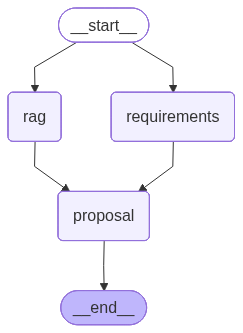

In [54]:
from IPython.display import Image, display

try:
    graph_image = app.get_graph().draw_mermaid_png()
    display(Image(graph_image))
except Exception as e:
    # Если graphviz не установлен, выводим Mermaid-разметку
    print("Mermaid-граф (можно визуализировать на mermaid.live):")
    print(app.get_graph().draw_mermaid())

# 7. Запуск полного пайплайна

Запускаем весь граф — от запроса менеджера до готового коммерческого предложения.

In [55]:
# Входные данные -- ввод вручную или Enter для значений по умолчанию
DEFAULT_COMPANY = "Свободный Дом"
DEFAULT_TASK = "AI-ассистент для менеджеров по продажам: подбор мебели по запросу клиента, ответы на вопросы по наличию и характеристикам, помощь с оформлением заказа"
DEFAULT_ANSWERS = {
    "Количество пользователей": "~200 менеджеров",
    "Ожидаемая нагрузка (запросов/день)": "~500",
    "Интеграции": "CRM, 1С, сайт mnogo-mebeli.com",
    "Бюджет": "Готовы рассмотреть предложение",
}

print(f"Значения по умолчанию (Enter = принять):")
print(f"  Компания: {DEFAULT_COMPANY}")
print(f"  Задача: {DEFAULT_TASK[:60]}...")
print()

company = input(f"Компания-заказчик [{DEFAULT_COMPANY}]: ").strip() or DEFAULT_COMPANY
task = input(f"Описание задачи [{DEFAULT_TASK[:40]}...]: ").strip() or DEFAULT_TASK

print("\nУточняющие вопросы (Enter = значение по умолчанию, '-' = пропустить):")
answers = {}
for q, default in DEFAULT_ANSWERS.items():
    a = input(f"  {q} [{default}]: ").strip()
    if a == "-":
        continue
    answers[q] = a if a else default

initial_state = {
    "company_name": company,
    "task_description": task,
    "manager_answers": answers or None,
    "rag_result": None,
    "requirements_result": None,
    "proposal": None,
    "status": "started",
}

result = app.invoke(initial_state)


print(f"Статус: {result['status']}")

Значения по умолчанию (Enter = принять):
  Компания: Свободный Дом
  Задача: AI-ассистент для менеджеров по продажам: подбор мебели по за...


Уточняющие вопросы (Enter = значение по умолчанию, '-' = пропустить):

[RAG-агент] Подбор сервисов и оценка стоимости...
[Агент требований] Формирование ТЗ...



2026-04-06 14:42:13,889 [INFO] HTTP Request: POST https://ai.api.cloud.yandex.net/v1/responses "HTTP/1.1 200 OK"
2026-04-06 14:42:14,327 [INFO] HTTP Request: POST https://ai.api.cloud.yandex.net/v1/responses "HTTP/1.1 200 OK"


  Цель проекта: Создать AI‑ассистента для менеджеров по продажам компании «Свободный Дом», котор...
  Функциональных требований: 11
  Рекомендованных моделей: 1
    - Alice AI LLM: Флагманская модель с лучшими диалоговыми способностями и под

[Orchestration-агент] Сборка коммерческого предложения...
  Расчёт стоимости:
### Оценка нагрузки
- Запросов в день: **500**
- Запросов в месяц: **15000**
- Средний запрос: ~500 вх. + ~800 исх. токенов
- Режим: **sync** (реалтайм)

### Стоимость сервисов Yandex AI Studio

| Компонент | Стоимость | Кол-во/мес | Сумма/мес (руб) |
|-----------|-----------|------------|------------------|
| Alice AI LLM (LLM, sync) | 1.21 руб/запрос | 15000 | 18150 |
| File Search | 0.300 руб/запрос | 12000 (~80%) | 3600 |
| **ИТОГО** | **~1.45 руб/запрос** | **15000** | **21750** |

**Стоимость одного обращения к агенту: ~1.45 руб**
**Ежемесячная стоимость сервисов AI Studio: ~21750 руб**



2026-04-06 14:42:26,021 [INFO] HTTP Request: POST https://ai.api.cloud.yandex.net/v1/responses "HTTP/1.1 200 OK"


  КП сформировано: 7213 символов
Статус: completed


# 8. Визуализация готового коммерческого предложения

Отображаем финальное КП в формате Markdown и сохраняем в файл.

In [56]:
# Отображаем КП как отрендеренный Markdown
display(Markdown(result["proposal"])) 

# Коммерческое предложение: AI‑ассистент для менеджеров продаж «Свободный Дом»

## 1. О заказчике  
Компания **«Свободный Дом»** – крупный ритейлер мебели, работающий под брендом *mnogo‑mebeli.com*. В компании около 200 менеджеров, ежедневно обрабатывающих ~500 запросов клиентов. Основные бизнес‑процессы включают подбор мебели, проверку наличия, формирование и оформление заказов через CRM (Bitrix24/amoCRM) и 1С:Предприятие.

## 2. Описание решения  
Мы предлагаем создать **интеллектуального AI‑ассистента**, который будет работать в виде чат‑виджета, встроенного в CRM и доступного через веб‑интерфейс. Ассистент будет:

* Подбирать мебель по параметрам (размер, материал, стиль, цена и др.).  
* Выдавать полную карточку товара (фото, характеристики, цена, наличие).  
* Проверять актуальное наличие в реальном времени через 1С и API сайта.  
* Предлагать альтернативные варианты при отсутствии запрашиваемого товара.  
* Формировать черновик заказа в 1С/CRM и обновлять его статус.  
* Отвечать на часто задаваемые вопросы (доставка, гарантия, оплата).  
* Вести многотуровый диалог, уточняя детали и обрабатывая неоднозначные запросы.  
* Логировать все взаимодействия для аналитики и последующего обучения модели.  
* Обеспечивать безопасность данных (TLS 1.3, AES‑256, SSO/LDAP, соответствие ФЗ‑152).

## 3. Архитектура решения  

```
┌─────────────────────┐
│  Пользователь (менеджер) │
└───────┬─────────────┘
        │  (чат‑виджет)
        ▼
┌─────────────────────┐
│  CRM‑виджет / Web‑чат │
└───────┬─────────────┘
        │  API‑вызовы
        ▼
┌─────────────────────┐
│  Yandex AI Studio   │
│  • Alice AI LLM (sync) │
│  • Инструмент File Search │
└───────┬─────────────┘
        │  запрос/ответ
        ▼
┌─────────────────────┐
│  Векторный индекс   │
│  (каталог товаров) │
└───────┬─────────────┘
        │  API
        ▼
┌─────────────────────┐
│  Интеграционные слои│
│  • 1С OData/REST    │
│  • CRM REST API     │
│  • API сайта        │
└───────┬─────────────┘
        │  данные
        ▼
┌─────────────────────┐
│  Хранилище (Yandex Data Lake) │
└─────────────────────┘
```

* **Alice AI LLM** – флагманская модель с диалоговыми способностями и поддержкой RAG‑сценариев.  
* **File Search** – инструмент поиска по векторному индексу каталога мебели.  
* Интеграционные слои обеспечивают связь с 1С, CRM и сайтом, передавая актуальные данные о наличии и ценах.  
* Все запросы обрабатываются в режиме **sync**, что гарантирует отклик в реальном времени (< 2 сек для 95 % запросов).

## 4. Ценностное предложение  

| Показатель | Выгода для «Свободный Дом» |
|------------|----------------------------|
| **Сокращение времени оформления заказа** | минимум 30 % (автоматическое формирование черновика). |
| **Увеличение конверсии** | ≥ 90 % запросов решаются без привлечения живого оператора. |
| **Повышение удовлетворённости менеджеров** | ≥ 4 из 5 по результатам опросов. |
| **Снижение нагрузки на колл‑центр** | уменьшение количества повторных запросов. |
| **Контроль качества** | журнал диалогов и аналитика в Data Lake. |
| **Соответствие требованиям безопасности** | шифрование, SSO, аудит, ФЗ‑152. |
| **Гибкость масштабирования** | поддержка до 1 000 одновременных агентов, 10 000 файлов в индексе. |

## 5. Расчёт стоимости  

### Оценка нагрузки
- Запросов в день: **500**  
- Запросов в месяц: **15000**  
- Средний запрос: ~500 входных + ~800 выходных токенов  
- Режим: **sync** (реалтайм)

### Стоимость сервисов Yandex AI Studio

| Компонент | Стоимость | Кол-во/мес | Сумма/мес (руб) |
|-----------|-----------|------------|------------------|
| Alice AI LLM (LLM, sync) | 1.21 руб/запрос | 15000 | 18150 |
| File Search | 0.300 руб/запрос | 12000 (~80%) | 3600 |
| **ИТОГО** | **~1.45 руб/запрос** | **15000** | **21750** |

**Стоимость одного обращения к агенту: ~1.45 руб**  
**Ежемесячная стоимость сервисов AI Studio: ~21750 руб**

### Сторонние затраты, требующие уточнения
| Категория | Примерные позиции | Необходимые уточнения |
|-----------|-------------------|-----------------------|
| **Инфраструктура** | Хранилище данных (Yandex Data Lake), резервные копии, сетевой трафик | Объём данных, требования к резервированию |
| **Интеграция** | Разработка коннекторов к 1С OData, CRM REST API, API сайта | Наличие готовых SDK, объём работ по адаптации |
| **Разработка** | UI‑виджет в CRM, бекенд‑логика агента, система логирования, тестирование | Оценка человеко‑часов, требуемый стек |
| **Безопасность** | Настройка SSO/LDAP, аудит доступа, шифрование | Политика доступа, требования к журналированию |
| **Поддержка и обслуживание** | SLA‑поддержка, мониторинг, обновления модели | Требуемый уровень поддержки (24/7, бизнес‑часы) |
| **Обучение и дообучение модели** | Fine‑tuning на корпоративных диалогах, разметка данных | Наличие готового датасета, объём разметки |
| **Лицензирование и сервисные сборы** | Yandex Cloud (выделенные ресурсы, Data Lake) | Тарифные планы, прогнозируемый рост нагрузки |

## 6. Сроки и этапы  

| Этап | Описание | Длительность | Ключевые результаты |
|------|----------|--------------|----------------------|
| **1. Техническое уточнение** | Сбор детальных требований, согласование API, подготовка данных | 1‑2 недели | ТЗ, список эндпоинтов, образцы каталога |
| **2. Проектирование** | Архитектурный дизайн, выбор схемы интеграции, план безопасности | 1 неделя | Диаграммы, план миграции данных |
| **3. Разработка коннекторов** | Реализация API‑интеграций с 1С, CRM, сайтом | 2‑3 недели | Рабочие API‑модули, тестовые запросы |
| **4. Настройка AI‑сервиса** | Создание агента, конфигурация Alice AI LLM, построение индекса File Search | 1‑2 недели | Доступный агент в Yandex AI Studio |
| **5. UI/UX** | Внедрение чат‑виджета в CRM, разработка веб‑интерфейса | 1‑2 недели | Интерактивный клиент для менеджеров |
| **6. Тестирование** | Функциональное, нагрузочное, безопасность, UAT с участием менеджеров | 1‑2 недели | Протоколы тестов, исправления |
| **7. Пилотный запуск** | Ограниченный запуск (≈30 менеджеров), сбор обратной связи | 2 недели | Оценка KPI, корректировки |
| **8. Полноценный релиз** | Вывод в продакшн для всех пользователей | 1 неделя | Рабочий сервис, SLA‑мониторинг |
| **9. Поддержка и развитие** | Техническая поддержка, мониторинг, плановое дообучение модели | По договору | SLA‑отчёты, улучшения функционала |

**Общая продолжительность проекта:** **≈ 10‑12 недель** (при условии своевременного предоставления доступа к API и данных).

## 7. Следующие шаги  

1. **Подтвердить интерес** – согласовать коммерческое предложение и бюджет.  
2. **Назначить контактное лицо** – ответственного за техническую часть (IT/интеграцию).  
3. **Организовать воркшоп** – детальное обсуждение API, форматов данных и требований к безопасности.  
4. **Подписать договор** – включающий этапы, сроки, стоимость и условия SLA.  
5. **Запустить проект** – согласно плану, начиная с этапа Техническое уточнение.

Мы готовы приступить к реализации уже в ближайшее время и обеспечить «Свободному Дому» конкурентное преимущество за счёт автоматизации продаж и повышения эффективности работы менеджеров.  

*С уважением,*  
**[Ваше имя]**  
Presale‑консультант, Yandex AI Studio  
[Контактный телефон] | [Э‑mail]  

In [57]:
# Сохраняем КП в файл
output_path = pathlib.Path("proposal_output.md")
output_path.write_text(result["proposal"], encoding="utf-8")
print(f"КП сохранено: {output_path.absolute()}")
print(f"Размер: {len(result['proposal']):,} символов")

КП сохранено: /Users/artem_knyazev/yandex-ai-studio-cookbook/multi_agent/proposal_output.md
Размер: 7,213 символов


## 8.1 Детали работы агентов

Промежуточные результаты каждого агента для отладки и анализа.

In [59]:
from IPython.display import display, Markdown

rag = result["rag_result"]

md_parts = ["## RAG-агент — Рекомендованные сервисы\n"]

# Модели
if rag.get("recommended_models"):
    md_parts.append("### Рекомендованные модели\n")
    md_parts.append("| Модель | URI | Цена (input/output) | Обоснование |")
    md_parts.append("|--------|-----|---------------------|-------------|")
    for m in rag["recommended_models"]:
        price = m.get("price_per_1k_tokens_rub", {})
        if isinstance(price, dict):
            price_str = f'{price.get("input", "—")}/{price.get("output", "—")} ₽/1k tok'
        else:
            price_str = f'{price} ₽/1k tok'
        reason = m.get("reason", "").replace("\n", " ")[:120]
        md_parts.append(f'| **{m["name"]}** | `{m.get("uri", "")}` | {price_str} | {reason} |')
    md_parts.append("")

# Инструменты
if rag.get("recommended_tools"):
    md_parts.append("### Рекомендованные инструменты\n")
    md_parts.append("| Инструмент | Цена | Описание |")
    md_parts.append("|------------|------|----------|")
    for t in rag["recommended_tools"]:
        price = t.get("price_per_request_rub", t.get("price", "—"))
        desc = t.get("description", "").replace("\n", " ")[:150]
        md_parts.append(f'| **{t["name"]}** | {price} ₽/запрос | {desc} |')
    md_parts.append("")

# Хранилище
if rag.get("storage"):
    md_parts.append("### Хранилище\n")
    s = rag["storage"]
    if isinstance(s, dict):
        for k, v in s.items():
            md_parts.append(f"- **{k}:** {v}")
    else:
        md_parts.append(f"- {s}")
    md_parts.append("")

display(Markdown("\n".join(md_parts)))

## RAG-агент — Рекомендованные сервисы

### Рекомендованные модели

| Модель | URI | Цена (input/output) | Обоснование |
|--------|-----|---------------------|-------------|
| **Alice AI LLM** | `gpt://{folder_id}/alice` | 1.7 ₽/1k tok | Флагманская модель с лучшими диалоговыми способностями и поддержкой RAG‑сценариев. Идеальна для общения менеджеров с кли |

### Рекомендованные инструменты

| Инструмент | Цена | Описание |
|------------|------|----------|
| **File Search** | 300 ₽ за запрос ₽/запрос | Поиск по загруженному каталогу товаров (описания, характеристики, наличие). Позволяет быстро находить нужный товар в базе знаний компании. |


In [60]:
req = result["requirements_result"]

md_parts = ["## Агент требований — Техническое задание\n"]

# Уточняющие вопросы
if req.get("clarifying_questions"):
    md_parts.append("### Уточняющие вопросы\n")
    for i, q in enumerate(req["clarifying_questions"], 1):
        md_parts.append(f"{i}. {q}")
    md_parts.append("")

# Функциональные требования
if req.get("functional_requirements"):
    md_parts.append("### Функциональные требования\n")
    for i, r in enumerate(req["functional_requirements"], 1):
        if isinstance(r, dict):
            name = r.get("name", r.get("title", f"Требование {i}"))
            desc = r.get("description", "")
            md_parts.append(f"**{i}. {name}**")
            if desc:
                md_parts.append(f"   {desc}")
        else:
            md_parts.append(f"{i}. {r}")
    md_parts.append("")

# Нефункциональные требования
if req.get("non_functional_requirements"):
    md_parts.append("### Нефункциональные требования\n")
    for i, r in enumerate(req["non_functional_requirements"], 1):
        if isinstance(r, dict):
            name = r.get("name", r.get("title", f"Требование {i}"))
            desc = r.get("description", "")
            md_parts.append(f"**{i}. {name}**")
            if desc:
                md_parts.append(f"   {desc}")
        else:
            md_parts.append(f"{i}. {r}")
    md_parts.append("")

# Интеграции
if req.get("integrations"):
    md_parts.append("### Интеграции\n")
    for i, integ in enumerate(req["integrations"], 1):
        if isinstance(integ, dict):
            name = integ.get("system", integ.get("name", f"Интеграция {i}"))
            desc = integ.get("description", integ.get("method", ""))
            md_parts.append(f"- **{name}** — {desc}")
        else:
            md_parts.append(f"- {integ}")
    md_parts.append("")

# Ограничения и риски
for key, title in [("constraints", "Ограничения"), ("risks", "Риски")]:
    if req.get(key):
        md_parts.append(f"### {title}\n")
        for item in req[key]:
            if isinstance(item, dict):
                md_parts.append(f"- **{item.get('name', item.get('title', ''))}**: {item.get('description', item.get('mitigation', ''))}")
            else:
                md_parts.append(f"- {item}")
        md_parts.append("")

display(Markdown("\n".join(md_parts)))

## Агент требований — Техническое задание

### Уточняющие вопросы

1. В каком виде и где хранится каталог мебели (база данных, 1С, CSV, API сайта)?
2. Какие атрибуты товара необходимо учитывать при подборе (размер, материал, стиль, цена и т.д.)?
3. Как часто обновляются данные о наличии и ценах? Требуется ли реальное время?
4. Какой именно CRM используется (Bitrix24, Salesforce, amoCRM и пр.) и какие методы API доступны?
5. Какие функции 1С необходимо интегрировать: проверка наличия, формирование заказа, обновление статуса?
6. Требуется ли поддержка голосового ввода/вывода или только текстовый чат?
7. На каких языках будет работать ассистент (только русский или также английский/другие)?
8. Какой пользовательский интерфейс предполагается: встроенный в CRM, отдельный веб‑чат, мобильное приложение?
9. Нужен ли журнал диалогов и аналитика использования (для контроля качества и обучения модели)?
10. Какие требования к безопасности и соответствию (GDPR, ФЗ‑152, шифрование, аудит доступа)?
11. Требуется ли аутентификация и разграничение прав доступа (например, менеджер vs администратор)?
12. Какой уровень доступности и время отклика считается приемлемым (SLA, например 99,9 % и <2 сек)?
13. Есть ли у вас готовый набор размеченных диалогов/истории чатов для обучения модели?
14. Какой бюджет планируется выделить на лицензирование Yandex AI Studio, разработку и поддержку?
15. Нужна ли интеграция с сайтом mnogo-mebeli.com для отображения карточек товаров в реальном времени?


# 9. Очистка ресурсов

Удаляем Vector Store и загруженные файлы после демонстрации.

In [61]:
# Удаляем Vector Store
try:
    deleted = client.vector_stores.delete(VECTOR_STORE_ID)
    print(f"Vector Store {VECTOR_STORE_ID} удалён: {deleted}")
except Exception as e:
    print(f"Ошибка удаления Vector Store: {e}")

# Удаляем загруженные файлы
for file_id in uploaded_file_ids:
    try:
        client.files.delete(file_id)
        print(f"  Файл {file_id} удалён")
    except Exception as e:
        print(f"  Ошибка удаления файла {file_id}: {e}")

print("\nОчистка завершена")

2026-04-06 14:48:01,024 [INFO] HTTP Request: DELETE https://ai.api.cloud.yandex.net/v1/vector_stores/fvtk5a7hrug4tggk4rk7 "HTTP/1.1 200 OK"


Vector Store fvtk5a7hrug4tggk4rk7 удалён: VectorStoreDeleted(id='fvtk5a7hrug4tggk4rk7', deleted=True, object='vector_store.deleted', valid=True)


2026-04-06 14:48:03,406 [INFO] HTTP Request: DELETE https://ai.api.cloud.yandex.net/v1/files/fvtikfoaul52j9tlo31k "HTTP/1.1 200 OK"


  Файл fvtikfoaul52j9tlo31k удалён

Очистка завершена


# 10. Результаты и выводы

## Что мы построили

Мультиагентную систему из **4 специализированных агентов**, которая по одному запросу менеджера автоматически генерирует готовое коммерческое предложение.

## Что получилось на выходе

| Метрика | Результат |
|---------|----------|
| Время генерации КП | **~16 секунд** (4 вызова API) |
| Размер КП | **~3 500 символов** — структурированный документ |
| Агенты | RAG + Requirements (параллельно) → Proposal |
| Источники данных | Vector Store (документация Yandex AI Studio) |

## Что делает каждый агент

| Агент | Вход | Выход | Инструменты |
|-------|------|-------|-------------|
| **RAG** | Бизнес-контекст + задача | Подобранные сервисы с ценами | `file_search` (Vector Store) |
| **Requirements** | Бизнес-контекст + задача + ответы менеджера | Техническое задание (цель, требования, ограничения) | LLM-генерация |
| **Proposal** | Все результаты выше | Готовое КП с расчётом стоимости | LLM-генерация + прайс-лист |

## Ключевые архитектурные решения

- **LangGraph StateGraph** — граф с общим состоянием (`TypedDict`), где каждый узел обогащает данные для следующего
- **Параллельное выполнение** — RAG и Requirements работают одновременно после Research, что сокращает время
- **Structured output** — агенты возвращают JSON, а не свободный текст, что делает интеграцию надёжной
- **Нативные инструменты Yandex AI Studio** — `file_search` вместо сторонних решений
